In [2]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.9/101.7 MB 19.3 MB/s eta 0:00:06
   --- ------------------------------------ 10.0/101.7 MB 24.8 MB/s eta 0:00:04
   ------ --------------------------------- 16.0/101.7 MB 26.1 MB/s eta 0:00:04
   --------- ------------------------------ 23.3/101.7 MB 28.3 MB/s eta 0:00:03
   ----------- ---------------------------- 28.6/101.7 MB 27.7 MB/s eta 0:00:03
   ------------- -------------------------- 34.1/101.7 MB 27.7 MB/s eta 0:00:03
   --------------- ------------------------ 40.1/101.7 MB 28.0 MB/s eta 0:00:03
   ------------------ --------------------- 46.1/101.7 MB 28.1 MB/s eta 0:00:02
   -------------------- ------------------- 51.4/101.7 MB 28.1 MB/s eta 0:00:02
   ---------------------- ----------------- 57.9/101.7 MB 28.1 MB/s eta 0:00:02
   ------------------------- -------------- 64.0/101.7 MB 28.2 MB/s eta 0:00:02
   --------------------------- ------------ 70.3/1

Train: 23189 | Test: 5798
[0]	validation_0-rmse:124.13034
[200]	validation_0-rmse:53.10040
[400]	validation_0-rmse:42.45423
[600]	validation_0-rmse:40.05866
[800]	validation_0-rmse:39.36274
[999]	validation_0-rmse:39.11129

══ TUNED XGBOOST RESULTS ══
RMSE : 39.11
MAE  : 13.02
R²   : 0.9021

══ FULL COMPARISON ══
Model                         RMSE      MAE       R²
----------------------------------------------------
Linear Regression            87.45    44.79   0.5020
Random Forest                37.47     9.34   0.9086
XGBoost (tuned)              39.11    13.02   0.9021


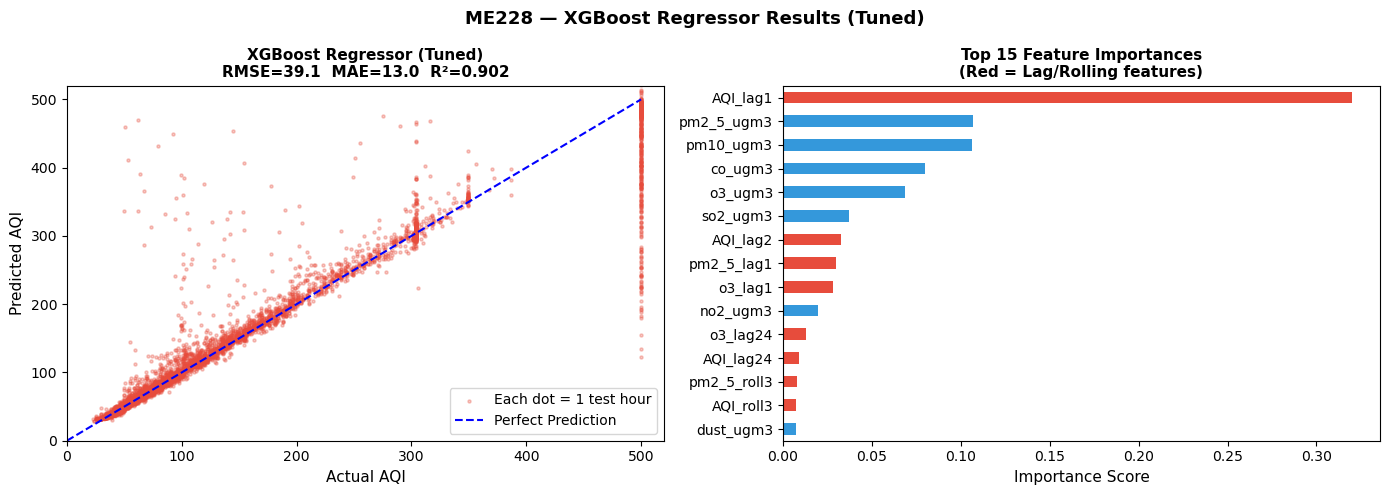

Model saved!


In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('Featured_Dataset.csv')

le = LabelEncoder()
df['season'] = le.fit_transform(df['season'])
bool_cols = ['is_weekend', 'is_raining', 'heavy_rain', 'festival_period', 'crop_burning_season']
for col in bool_cols:
    df[col] = df[col].astype(int)

drop_cols = ['datetime', 'aqi_category', 'pm25_category_india',
             'dominant_pollutant', 'humidity_category', 'wind_category', 'time_of_day']
X = df.drop(columns=drop_cols + ['AQI'])
y = df['AQI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── TUNED XGBOOST ──
xgb = XGBRegressor(
    n_estimators=1000,       # more trees
    learning_rate=0.01,      # slower learning = better generalization
    max_depth=7,             # slightly deeper trees
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,      # prevents overfitting
    gamma=0.1,               # prevents overfitting
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=200)

y_pred = xgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("\n══ TUNED XGBOOST RESULTS ══")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

print("\n══ FULL COMPARISON ══")
print(f"{'Model':<25} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 52)
print(f"{'Linear Regression':<25} {'87.45':>8} {'44.79':>8} {'0.5020':>8}")
print(f"{'Random Forest':<25} {'37.47':>8} {'9.34':>8} {'0.9086':>8}")
print(f"{'XGBoost (tuned)':<25} {rmse:>8.2f} {mae:>8.2f} {r2:>8.4f}")

# ── PLOTS ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=5, color='#e74c3c', label='Each dot = 1 test hour')
axes[0].plot([0, 500], [0, 500], 'b--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual AQI', fontsize=11)
axes[0].set_ylabel('Predicted AQI', fontsize=11)
axes[0].set_title(f'XGBoost Regressor (Tuned)\nRMSE={rmse:.1f}  MAE={mae:.1f}  R²={r2:.3f}',
                  fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 520)
axes[0].set_ylim(0, 520)

feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(15)
colors = ['#e74c3c' if 'lag' in i or 'roll' in i else '#3498db' for i in feat_imp.index]
feat_imp.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Top 15 Feature Importances\n(Red = Lag/Rolling features)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=11)

plt.suptitle('ME228 — XGBoost Regressor Results (Tuned)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ME228_XGBoost_Regressor.png', dpi=150, bbox_inches='tight')
plt.show()

# ── SAVE ──
joblib.dump(xgb, 'xgboost_regressor.pkl')
joblib.dump(le, 'season_encoder.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')
print("Model saved!")